<a href="https://colab.research.google.com/github/Christianib003/rekomai/blob/clint/notebooks/image_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Data Collection and Processing

In [2]:
# 1. Setup & Imports
!pip install deepface albumentations opencv-python --quiet

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from deepface import DeepFace
import albumentations as A
from albumentations import HorizontalFlip, Rotate, ToGray


In [3]:
# Clone the GitHub repo with images
!git clone https://github.com/Christianib003/rekomai.git

Cloning into 'rekomai'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 103 (delta 44), reused 41 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 948.97 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (44/44), done.


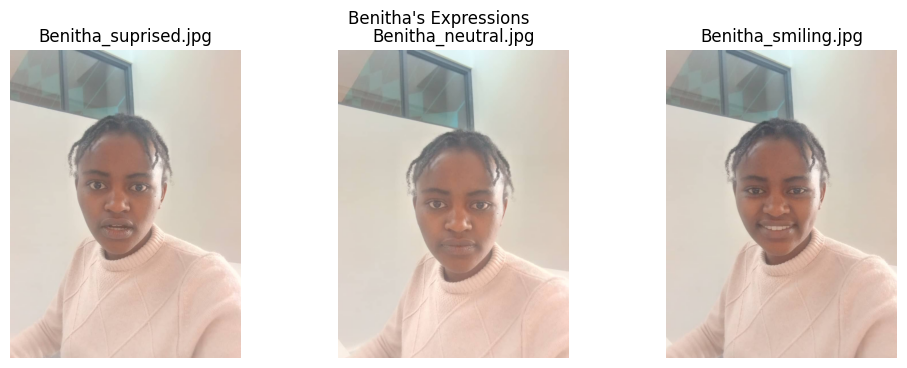

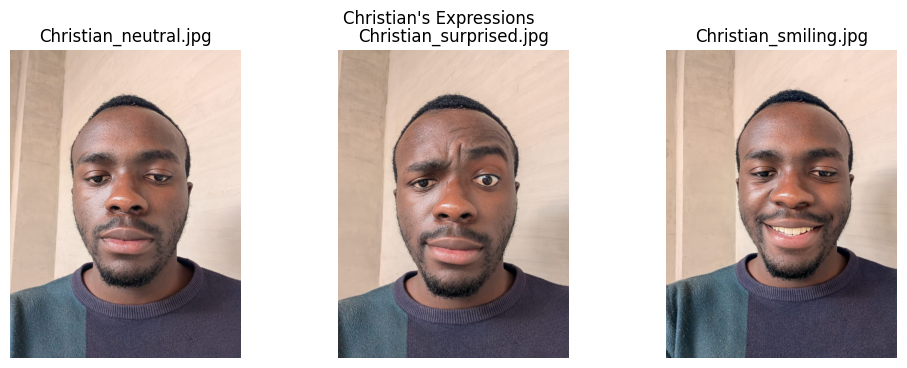

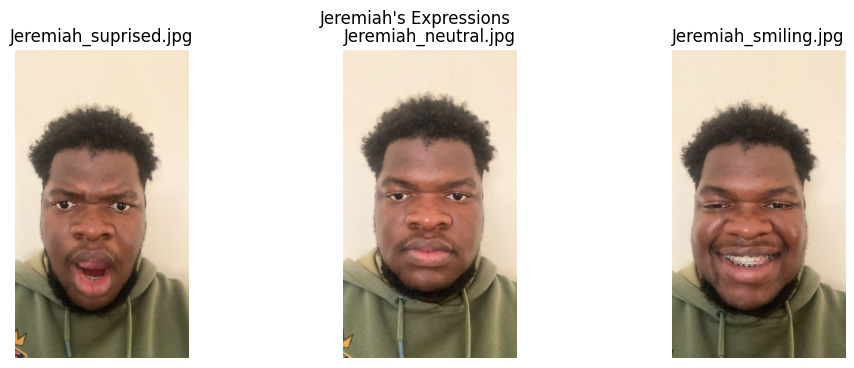

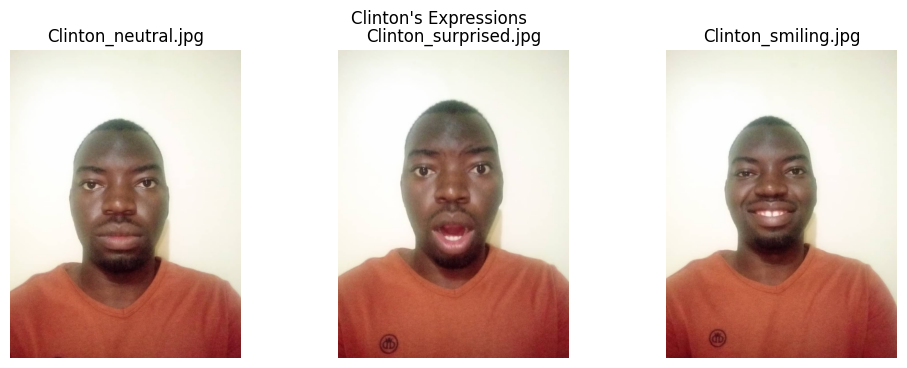

In [5]:
# 2. Display Original Images
def load_and_display_images(base_path='rekomai/data/images/'):
    members = os.listdir(base_path)
    for member in members:
        folder = os.path.join(base_path, member)
        if os.path.isdir(folder): # Add this check to ensure it's a directory
            images = [os.path.join(folder, img) for img in os.listdir(folder) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

            plt.figure(figsize=(12, 4))
            for idx, img_path in enumerate(images):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, len(images), idx+1)
                plt.imshow(img)
                plt.title(os.path.basename(img_path))
                plt.axis('off')
            plt.suptitle(f"{member}'s Expressions")
            plt.show()

load_and_display_images()

In [6]:
# 3. Define Augmentation Pipeline using Albumentations
augment = A.Compose([
    HorizontalFlip(p=1.0),    # Flip horizontally
    Rotate(limit=20, p=1.0),  # Rotate within ±20 degrees
    ToGray(p=1.0),            # Convert to grayscale
])

def apply_augmentations(image):
    augmented = augment(image=image)
    return augmented['image']

In [7]:
# 4. Extract Face Embeddings using DeepFace
def extract_embedding(img_path):
    try:
        embedding = DeepFace.represent(img_path=img_path, model_name='Facenet')[0]['embedding']
        return embedding
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return [None] * 128  # fallback placeholder

In [10]:
# 5. Process and Save Features
data = []

def process_member_images(base_path='rekomai/data/images/'):
    for member in os.listdir(base_path):
        folder = os.path.join(base_path, member)
        if os.path.isdir(folder): # Add this check to ensure it's a directory
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(folder, img_file)

                    # Optional: Apply augmentation to each image before feature extraction
                    # image = cv2.imread(img_path)
                    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    # image = apply_augmentations(image)

                    embedding = extract_embedding(img_path)
                    data.append({
                        'user_id': member,
                        'expression': img_file.split('.')[0],
                        'image_path': img_path,
                        **{f'feat_{i}': val for i, val in enumerate(embedding)}
                    })

process_member_images()

25-07-24 09:58:19 - facenet_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 112MB/s]


Error processing rekomai/data/images/Clinton/Clinton_surprised.jpg: Face could not be detected in rekomai/data/images/Clinton/Clinton_surprised.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.


In [11]:
# Convert to DataFrame and Save
image_features_df = pd.DataFrame(data)

In [15]:
# Ensure directory exists
os.makedirs("data/customer-info", exist_ok=True)
image_features_df.to_csv("data/customer-info/image_features.csv", index=False)

In [14]:
# 6. Preview Feature Dataset
image_features_df.head()
image_features_df.tail()

,user_id,expression,image_path,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127
7,Jeremiah,Jeremiah_neutral,rekomai/data/images/Jeremiah/Jeremiah_neutral.jpg,1.442714,-0.724281,2.451543,0.263665,1.012525,0.564195,1.534975,...,0.037971,-1.621410,0.792631,0.350497,2.035460,-0.044654,0.862122,0.285014,1.026445,0.860589
8,Jeremiah,Jeremiah_smiling,rekomai/data/images/Jeremiah/Jeremiah_smiling.jpg,1.997515,-0.299704,1.787953,-0.494293,1.773624,0.793494,1.772766,...,-0.577614,-0.803517,0.606808,-0.173191,2.810657,0.351706,0.430406,0.487196,1.551907,1.262871
9,Clinton,Clinton_neutral,rekomai/data/images/Clinton/Clinton_neutral.jpg,-0.299216,-0.368950,0.494496,-0.583860,-0.532669,0.945372,0.585232,...,-0.410005,1.084970,1.511801,-0.770401,1.429548,-0.320726,1.698014,-1.534750,2.026111,1.134802
10,Clinton,Clinton_surprised,rekomai/data/images/Clinton/Clinton_surprised.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Clinton,Clinton_smiling,rekomai/data/images/Clinton/Clinton_smiling.jpg,0.371145,0.375184,0.301044,-0.930934,-0.243010,1.352414,0.359641,...,-1.233692,1.166248,1.280913,-0.856379,0.712329,0.056203,1.240532,-1.587739,1.900460,0.236433
